# Feature Extraction Model Using the Focal Loss Function


# Table of Contents
1. [Loading Data](#Loading-Data)
2. [Labels](#Labels)
3. [Data Processing](#Data-Processing)
4. [Building Model](#Building-Model)
5. [Visualizations](#visualizations)
6. [Evaluation](#Evaluation)

## Loading Data

In [15]:
#loading data
import pandas as pd
import zipfile
import chardet
import io


zip_path = 'v2_combined-20260406T063631Z-1-001.zip'


data_dict = {}

with zipfile.ZipFile(zip_path, 'r') as z:
    # Get list of all files in the zip
    files = z.namelist()
    
    for file_name in files:
        if file_name.endswith('.csv'):
            with z.open(file_name) as f:
           
                raw_data = f.read(20000) 
                result = chardet.detect(raw_data)
                enc = result['encoding']
                
              
                f.seek(0)
                print(f"Loading {file_name} with detected encoding: {enc}")
                
                try:
                    # Some files might still fail if encoding is ambiguous; fallback to 'latin1'
                    data_dict[file_name] = pd.read_csv(f, encoding=enc)
                except Exception as e:
                    print(f"Failed with {enc}, trying 'latin1' fallback for {file_name}")
                    f.seek(0)
                    data_dict[file_name] = pd.read_csv(f, encoding='latin1')


print("\nSuccessfully loaded DataFrames:", list(data_dict.keys()))

Loading v2_combined/data_chunk_4.csv with detected encoding: utf-8
Loading v2_combined/data_chunk_1.csv with detected encoding: utf-8
Loading v2_combined/data_chunk_0.csv with detected encoding: utf-8
Loading v2_combined/data_chunk_6.csv with detected encoding: utf-8
Loading v2_combined/Reviews/reviews_chunk_14.csv with detected encoding: ascii
Failed with ascii, trying 'latin1' fallback for v2_combined/Reviews/reviews_chunk_14.csv
Loading v2_combined/Reviews/reviews_chunk_10.csv with detected encoding: ascii
Failed with ascii, trying 'latin1' fallback for v2_combined/Reviews/reviews_chunk_10.csv
Loading v2_combined/Reviews/reviews_chunk_3.csv with detected encoding: Windows-1252
Failed with Windows-1252, trying 'latin1' fallback for v2_combined/Reviews/reviews_chunk_3.csv
Loading v2_combined/data_chunk_7.csv with detected encoding: utf-8
Loading v2_combined/data_chunk_2.csv with detected encoding: utf-8
Loading v2_combined/Reviews/reviews_chunk_5.csv with detected encoding: ascii
Fail

In [16]:
data_keys = [k for k in data_dict.keys() if 'data_chunk' in k]
review_keys = [k for k in data_dict.keys() if 'reviews_chunk' in k]



df_main_data = pd.concat([data_dict[k] for k in data_keys], axis=0, ignore_index=True).drop_duplicates()


df_reviews = pd.concat([data_dict[k] for k in review_keys], axis=0, ignore_index=True).drop_duplicates()

print(f"Main Data Rows: {len(df_main_data)}")
print(f"Review Rows: {len(df_reviews)}")

Main Data Rows: 572215
Review Rows: 3794003


In [17]:
df_main_data = df_main_data.rename(columns={'RecipeId': 'recipe_id'})

In [18]:
# Extracting images from kaggle
import kagglehub

path = kagglehub.dataset_download("elisaxxygao/foodrecsysv1")
IMG_DIR = f"{path}/raw-data-images/raw-data-images"

df_kaggle_lookup = pd.read_csv(f"{path}/core-data_recipe.csv")[['recipe_id']]
df_kaggle_lookup['image_path'] = df_kaggle_lookup['recipe_id'].apply(lambda x: f"{IMG_DIR}/{x}.jpg")



final_recipe_df = pd.merge(
    df_main_data, 
    df_kaggle_lookup, 
    on='recipe_id', 
    how='inner'
)


print(f"Total recipes with images and metadata: {len(final_recipe_df)}")

Total recipes with images and metadata: 89937


## Labels 

In [19]:

vocab_df  = pd.read_csv('ingredient_counts_ingredients_canonical_final_le_5_replace.csv')
label_col = vocab_df.columns[0]  # ingredients_canonical_final
vocab     = {ing: idx for idx, ing in enumerate(vocab_df[label_col])}

print(f"Vocab size: {len(vocab)}")
print(f"Top 10: {list(vocab.keys())[:10]}")

Vocab size: 5442
Top 10: ['salt', 'onion', 'sugar', 'butter', 'garlic', 'egg', 'olive oil', 'water', 'milk', 'flour']


## Data Processing

In [20]:
import os, re, pickle, torch, requests
import torch.nn as nn
import pandas as pd
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
import kagglehub
import numpy as np

In [21]:
train_df, temp_df = train_test_split(
    final_recipe_df, 
    test_size=0.4, 
    random_state=42, 
    shuffle=True
)


val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42, 
    shuffle=True
)


print(f"Final Combined Dataset: {len(final_recipe_df)} rows")
print("-" * 30)
print(f"Train Set: {len(train_df)} rows (60%)")
print(f"Val Set:   {len(val_df)} rows (20%)")
print(f"Test Set:  {len(test_df)} rows (20%)")

Final Combined Dataset: 89937 rows
------------------------------
Train Set: 53962 rows (60%)
Val Set:   17987 rows (20%)
Test Set:  17988 rows (20%)


In [22]:
class RecipeDataset(Dataset):
    def __init__(self, df, vocab, transform=None):
        self.df        = df.reset_index(drop=True)
        self.vocab     = vocab
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image
        try:
            image = Image.open(row['image_path']).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224))

        if self.transform:
            image = self.transform(image)

        # Parse ingredients
        label = torch.zeros(len(self.vocab))
        try:
            ingredients = ast.literal_eval(row['ingredients_canonical_final'])
            for ing in ingredients:
                ing = ing.lower().strip()
                if ing in self.vocab:
                    label[self.vocab[ing]] = 1.0
        except:
            pass

        return image, label

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(RecipeDataset(train_df, vocab, train_transform), batch_size=8, shuffle=True,  num_workers=1)
val_loader   = DataLoader(RecipeDataset(val_df,   vocab, test_transform),  batch_size=8, shuffle=False, num_workers=1)
test_loader  = DataLoader(RecipeDataset(test_df,  vocab, test_transform),  batch_size=8, shuffle=False, num_workers=1)

print(f"Train: {len(train_loader.dataset)} | Val: {len(val_loader.dataset)} | Test: {len(test_loader.dataset)}")

Train: 53962 | Val: 17987 | Test: 17988


In [23]:
import ast
# Check val labels
for images, labels in val_loader:
    print(f"Label sum per sample: {labels.sum(dim=1)[:5]}")
    print(f"Max label value: {labels.max()}")
    break

# Check a sample from val_df
sample = val_df['ingredients_canonical_final'].iloc[0]
print(f"\nVal sample: {repr(sample)}")
parsed = ast.literal_eval(sample)
print(f"Parsed: {parsed[:3]}")

# Check matches
for ing in parsed[:5]:
    ing_clean = ing.lower().strip()
    print(f"  '{ing_clean}' in vocab: {ing_clean in vocab}")

Label sum per sample: tensor([10., 14.,  3.,  5.,  6.])
Max label value: 1.0

Val sample: "['all purpose flour', 'sugar', 'baking soda', 'salt', 'nutmeg', 'cinnamon', 'shortening', 'egg', 'banana', 'rolled oat']"
Parsed: ['all purpose flour', 'sugar', 'baking soda']
  'all purpose flour' in vocab: True
  'sugar' in vocab: True
  'baking soda' in vocab: True
  'salt' in vocab: True
  'nutmeg' in vocab: True


## Building Model

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
# Building the focal loss function

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma      = gamma
        self.pos_weight = pos_weight

    def forward(self, inputs, targets):
        # BCE with pos_weight for class imbalance
        bce = F.binary_cross_entropy_with_logits(
            inputs, targets,
            pos_weight=self.pos_weight,
            reduction='none'
        )

        # Focal weight — down-weight easy examples
        probs   = torch.sigmoid(inputs)
        pt      = torch.where(targets == 1, probs, 1 - probs)
        focal   = ((1 - pt) ** self.gamma) * bce

        return focal.mean()


# Build pos_weight
counts_tensor = torch.zeros(len(vocab))
for ing, count in zip(vocab_df['Ingredient'], vocab_df['Count']):
    if ing in vocab:
        counts_tensor[vocab[ing]] = count

pos_weight = torch.clamp(
    (len(train_df) - counts_tensor) / (counts_tensor + 1e-6),
    min=1.0,
    max=5.0
)


criterion = FocalLoss(gamma=2.0, pos_weight=pos_weight.to(device))

In [25]:
def get_frozen_model(checkpoint_path):
    model = models.resnet50()
    ckpt  = torch.load(checkpoint_path, map_location='cpu', weights_only=False,encoding='latin1')
    
    # Load vision weights
    state_dict = {
        k.replace('visionMLP.module.', ''): v.float()
        for k, v in ckpt['state_dict'].items()
        if 'visionMLP' in k
    }
    model.load_state_dict(state_dict, strict=False)
    
    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False

    # New head 
    model.fc = nn.Linear(2048, len(vocab))
    return model

In [12]:
from tqdm import tqdm
def train_final_layer(model, train_loader, val_loader, epochs=20):
    counts_tensor = torch.zeros(len(vocab))
    for ing, count in zip(vocab_df['Ingredient'], vocab_df['Count']):
        if ing in vocab:
            counts_tensor[vocab[ing]] = count

    pos_weight = torch.clamp(
        (len(train_df) - counts_tensor) / (counts_tensor + 1e-6),
        min=1.0, max=5.0
    )

    # Focal loss
    criterion     = FocalLoss(gamma=2.0, pos_weight=pos_weight.to(device))
    best_val_loss = float('inf')
    optimizer     = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
    scheduler     = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

    train_losses = []
    val_losses   = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                val_loss += criterion(model(images), labels).item()

        avg_train = train_loss / len(train_loader)
        avg_val   = val_loss   / len(val_loader)
        train_losses.append(avg_train)
        val_losses.append(avg_val)
        scheduler.step()

        print(f"Epoch {epoch+1}/{epochs} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save({
                'state_dict': model.state_dict(),
                'vocab':      vocab
            }, 'best_ingredient_model_focal_loss.pth')
            print(f"  ✓ Saved best model (Val Loss: {best_val_loss:.4f})")

    return train_losses, val_losses


# Reset and retrain
resnet = get_frozen_model('model_e220_v-4.700.pth.tar').to(device)
train_losses, val_losses = train_final_layer(resnet, train_loader, val_loader, epochs=8)

Epoch 1: 100%|██████████| 6746/6746 [09:47<00:00, 11.48it/s]


Epoch 1/8 | Train: 0.0217 | Val: 0.0239
  ✓ Saved best model (Val Loss: 0.0239)


Epoch 2: 100%|██████████| 6746/6746 [08:31<00:00, 13.20it/s]


Epoch 2/8 | Train: 0.0225 | Val: 0.0255


Epoch 3: 100%|██████████| 6746/6746 [08:32<00:00, 13.17it/s]


...

Epoch 6/8 | Train: 0.0096 | Val: 0.0086
  ✓ Saved best model (Val Loss: 0.0086)


Epoch 7: 100%|██████████| 6746/6746 [08:34<00:00, 13.12it/s]


Epoch 7/8 | Train: 0.0072 | Val: 0.0074
  ✓ Saved best model (Val Loss: 0.0074)


Epoch 8: 100%|██████████| 6746/6746 [08:33<00:00, 13.15it/s]


Epoch 8/8 | Train: 0.0069 | Val: 0.0081


## Visualizations

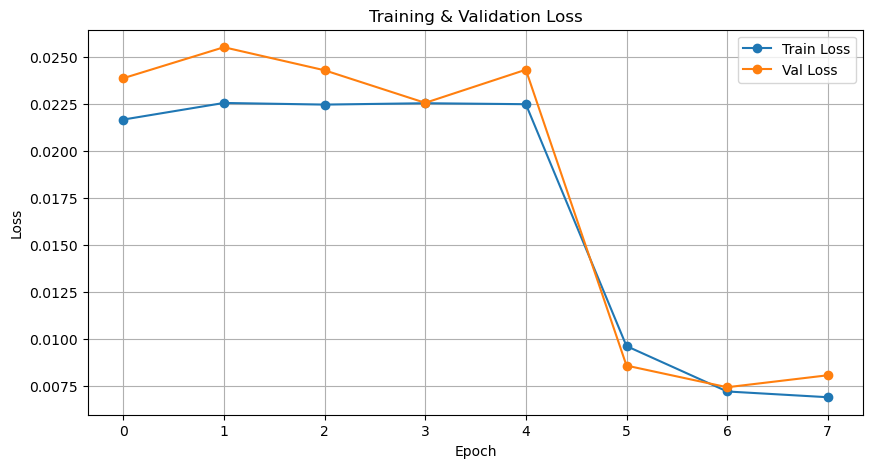

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses,   label='Val Loss',   marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve.png')
plt.show()

In [29]:
import numpy as np
resnet = get_frozen_model('model_e220_v-4.700.pth.tar').to(device)
idx_to_ing = {v: k for k, v in vocab.items()}
def get_cluster_data(model, loader, idx_to_ing, max_samples=500):
    model.eval()
    embeddings = []
    top_preds = []
    
   
    original_fc = model.fc
    model.fc = torch.nn.Identity()
    
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            images = images.to(device)
            
           
            feat = model(images)
            embeddings.append(feat.cpu().numpy())
            
            # 2. Get predictions using the original weights
            # (Manually applying the old FC layer)
            logits = original_fc(feat)
            probs = torch.sigmoid(logits)
            
            # Get the single most confident ingredient for coloring
            top_idx = torch.argmax(probs, dim=1)
            for idx in top_idx:
                top_preds.append(idx_to_ing[idx.item()])
            
            if len(embeddings) * loader.batch_size >= max_samples:
                break
                
    model.fc = original_fc # Put it back!
    return np.vstack(embeddings), top_preds


features, labels = get_cluster_data(resnet, val_loader, idx_to_ing, max_samples=600)

In [30]:
from sklearn.manifold import TSNE
import plotly.express as px
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42)
projections = tsne.fit_transform(features)


df = pd.DataFrame({
    'x': projections[:, 0],
    'y': projections[:, 1],
    'ingredient': labels
})

fig = px.scatter(
    df, x='x', y='y', 
    color='ingredient',
    title='Ingredient Clusters (ResNet-50 Embeddings)',
    hover_name='ingredient',
    template='plotly_dark'
)

fig.update_traces(marker=dict(size=8, opacity=0.7))
fig.show()

## Evaluation

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet50(weights=None) 


model.fc = nn.Linear(model.fc.in_features, len(vocab)) 


checkpoint = torch.load('best_ingredient_model_focal_loss.pth')
model.load_state_dict(checkpoint['state_dict'])

model.to(device)

all_preds = []
all_labels = []


with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        
        # Convert logits to probabilities, then to binary (0/1)
     
        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
        
        all_preds.append(preds)
        all_labels.append(labels.cpu().numpy())

y_true = np.vstack(all_labels)
y_pred = np.vstack(all_preds)


precision = precision_score(y_true, y_pred, average='samples', zero_division=0)
recall = recall_score(y_true, y_pred, average='samples', zero_division=0)
f1 = f1_score(y_true, y_pred, average='samples', zero_division=0)

print(f"--- Final Evaluation (Per-Recipe Average) ---")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

--- Final Evaluation (Per-Recipe Average) ---
Precision: 0.0019
Recall:    0.0006
F1 Score:  0.0008


In [12]:
from sklearn.metrics import jaccard_score

model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        
        # Binary predictions (using your best threshold, e.g., 0.5)
        preds = (torch.sigmoid(outputs) > 0.3).cpu().numpy()
        test_preds.append(preds)
        test_labels.append(labels.cpu().numpy())

y_test_true = np.vstack(test_labels)
y_test_pred = np.vstack(test_preds)


final_test_jaccard = jaccard_score(y_test_true, y_test_pred, average='samples')
print(f"Final Test Jaccard Similarity: {final_test_jaccard:.4f}")

Final Test Jaccard Similarity: 0.0463


In [13]:
import torch.nn.functional as F
from sklearn.metrics.pairwise import cosine_similarity

model.eval()
all_similarities = []

print("Calculating Cosine Similarity for the Test Set...")

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).float()
        
       
        logits = model(images)
        probs = torch.sigmoid(logits)
        
        # Calculate Cosine Similarity for the batch
        # F.cosine_similarity computes along dim 1 (the ingredient vector)
        # We use probabilities (0.0 to 1.0) rather than hard 0/1 for a smoother semantic score
        batch_sim = F.cosine_similarity(labels, probs, dim=1)
        
        all_similarities.extend(batch_sim.cpu().numpy())

avg_cosine_sim = np.mean(all_similarities)

print("-" * 30)
print(f"FINAL TEST SET RESULTS")
print("-" * 30)
print(f"Avg Cosine Similarity: {avg_cosine_sim:.4f}")

Calculating Cosine Similarity for the Test Set...
------------------------------
FINAL TEST SET RESULTS
------------------------------
Avg Cosine Similarity: 0.1265


The  low F1 Score (0.0008) and Recall (0.0006) indicate that the model is currently failing to identify ingredients. The Jaccard Similarity (0.0463) shows a slight baseline overlap in sets, and the Avg Cosine Similarity (0.1265) suggests that the image and text embeddings are not yet effectively aligned in a shared space. Ultimately, these results suggest that the model likely lacks the discriminative power required to distinguish between highly similar food categories.